# **Task 2: Exploratory Data Analysis on Titanic Dataset**
### Description:
- Dataset (Recommended): Titanic: Machine Learning from Disaster (Kaggle)
- Explore the classic Titanic dataset using Python
- Perform data cleaning: handle missing values, convert types
- Generate summary statistics and group-based insights (e.g., survival by gender/class)
- Visualize key patterns and correlations
                        
### Tools & Libraries:
- Python Pandas Seaborn or Matplotlib    
### Covered Topics:
-  EDA | Data types & missing data| Data visualization   
### Bonus:
- Visualize survival rates using bar plots and heatmaps                                 


### **LOAD DATASET** 

In [41]:
import pandas as pd 

In [42]:
data=pd.read_csv("dataset/train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [44]:
data.shape

(891, 12)

## DATA CLEANING

### CHECK MISSING VALUE

In [45]:
missing =data.isnull().sum()
missing 


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## **Missing Values Handling**
### **Age Column (Numerical)**

The `Age` column contains missing numerical values (**177 instances**).

**Strategy:**

* Imputed missing values using the **median**.

**Reasoning:**
Since age is a continuous variable and the Titanic dataset includes outliers (very young and very old passengers), the median preserves the central tendency better than the mean, which can be skewed by extreme values.

### **Embarked Column (Categorical)**

The `Embarked` column is a categorical variable with only **2 missing values**.

**Strategy:**

* Imputed missing values using the **mode** (most frequent category).

**Reasoning:**
Given the very small number of missing entries, using the most common port of embarkation maintains the original category distribution without introducing significant bias.

### **Cabin Column (Dropped)**
Cabin column was dropped because it contains too many missing values (over 75%).


**Reasoning:**
Imputing such a large amount of missing data would introduce noise and unreliable information.
Therefore, the column was removed to keep the dataset clean and avoid misleading analysis.



###  Summary

* Numerical values were imputed using robust statistical methods.
* Categorical values were imputed to preserve distributions.
* The Cabin column was dropped due to extreme sparsity, which could negatively affect data quality and analysis results.


In [46]:

data['Age'].fillna(data['Age'].median(), inplace=True)

C:\Users\toshiba\AppData\Local\Temp\ipykernel_14840\3607808044.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)


In [47]:
data["Embarked"].fillna(data["Embarked"].mode()[0],inplace=True)

C:\Users\toshiba\AppData\Local\Temp\ipykernel_14840\2172230697.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Embarked"].fillna(data["Embarked"].mode()[0],inplace=True)


In [48]:
data.drop(columns=["Cabin"],inplace=True)

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [50]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### **Data Type check**

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


### **Data Type Conversion**
 The columns **Survived**, **Pclass**, **Sex**, and **Embarked** were converted to categorical data types because they represent labels or groups rather than numerical quantities. *Survived* indicates a binary outcome (Yes/No), *Pclass* represents passenger class categories, *Sex* denotes gender groups, and *Embarked* identifies boarding locations. Treating these variables as categorical improves the clarity of summary statistics and ensures that visualizations such as bar plots correctly display grouped comparisons instead of misleading numerical relationships.

In [52]:

categorical_columns = ['Pclass', 'Sex', 'Embarked']

for col in categorical_columns:
    data[col] = data[col].astype('category')

print(data[categorical_columns].dtypes)


Pclass      category
Sex         category
Embarked    category
dtype: object


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(3), float64(2), int64(4), object(2)
memory usage: 58.8+ KB


# Summary Statistics 


### Summary Statistics for numerical columns


In [54]:
data.describe()



,PassengerId,Survived,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,80.000000,8.000000,6.000000,512.329200


### summary Statistics for Categorical Column


In [55]:
#summary statistics for categorical columns
data.select_dtypes(include=['category', 'object']).describe()

,Pclass,Name,Sex,Ticket,Embarked
count,891,891,891,891,891
unique,3,891,2,681,3
top,3,"Braund, Mr. Owen Harris",male,347082,S
freq,491,1,577,7,646


## Group-Based

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
data1=data.groupby(["Sex","Pclass"])["Survived"].mean()
print(data1)


Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64


C:\Users\toshiba\AppData\Local\Temp\ipykernel_14840\2408075636.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data1=data.groupby(["Sex","Pclass"])["Survived"].mean()


### Group-based Survival Analysis by Sex and Passenger Class
*Female passengers had very high survival rates, especially in 1st and 2nd class. Survival decreases significantly for females in 3rd class, showing that passenger class influenced survival even among females.*
 - **Female Passengers**

- 1st class females: Survival rate ≈ 96.8%

- 2nd class females: Survival rate ≈ 92.1%

- 3rd class females: Survival rate = 50%
  
*Male passengers had much lower survival rates compared to females across all classes. Even in 1st class, male survival was below 40%, and it dropped further in lower classes.*
 - **Male Passengers**

 - 1st class males: Survival rate ≈ 36.9%

 - 2nd class males: Survival rate ≈ 15.7%

 - 3rd class males: Survival rate ≈ 13.5%
  
  

**The analysis shows that gender and passenger class significantly influenced survival outcomes.
Female passengers had substantially higher survival rates than males across all classes.
Survival rates were highest for first-class females (96.8%) and lowest for third-class males (13.5%).
This indicates that both social factors (gender) and economic status (class) played a critical role in survival during the Titanic disaster.**






## **Visualize KEY PATTERNS AND CORRELATION**

### **Survived By Sex**

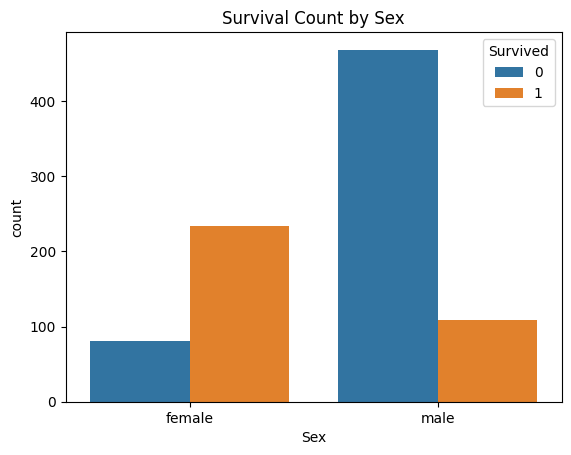

In [58]:
#  Blue   for Died (0), orange  for Survived (1)

sns.countplot(x='Sex', hue='Survived', data=data)
plt.title('Survival Count by Sex')
plt.show()

**Female passengers show a higher survival count compared to male passengers, indicating that gender played a significant role in survival.**

### **Survival By Passenger class**

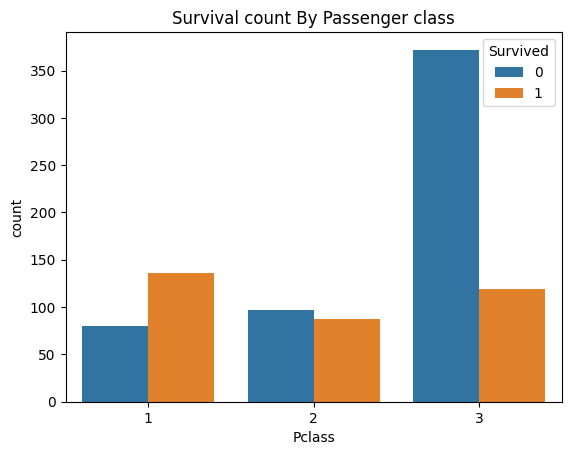

In [59]:
#  Blue   for Died (0), orange  for Survived (1)
sns.countplot(x="Pclass",hue="Survived",data=data)
plt.title("Survival count By Passenger class")
plt.show()

**First-class passengers had higher survival counts compared to second and third-class passengers.**

## **Bonus** 
### **visualize survival rate using bar plots and heatmaps**


  BAR PLOT 

C:\Users\toshiba\AppData\Local\Temp\ipykernel_14840\1872045742.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = data.groupby('Sex')['Survived'].mean()


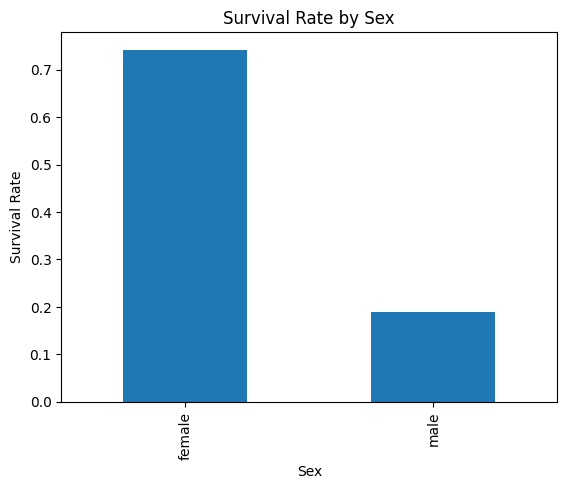

In [60]:
survival_rate = data.groupby('Sex')['Survived'].mean()

survival_rate.plot(kind='bar')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()


#### **The survival rate of female passengers is significantly higher than that of male passengers.**

HEAT MAP

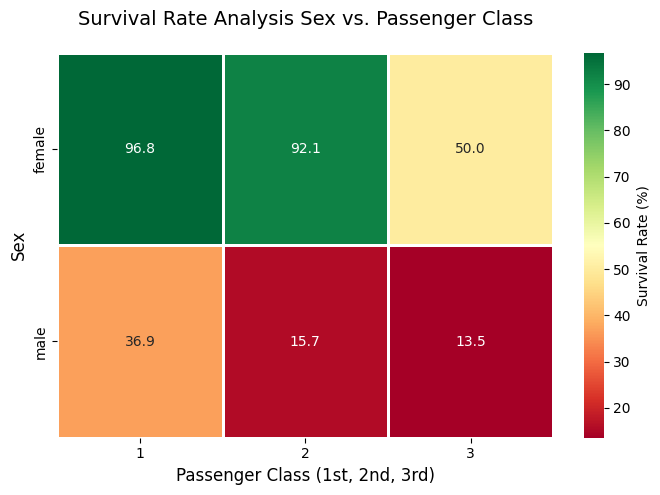

In [61]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    survival_pivot * 100,      
    annot=True, 
    fmt=".1f",                 
    cmap='RdYlGn', 
    linewidths=1,
    cbar_kws={'label': 'Survival Rate (%)'} 
)

plt.title('Survival Rate Analysis Sex vs. Passenger Class', fontsize=14, pad=20)
plt.xlabel('Passenger Class (1st, 2nd, 3rd)', fontsize=12)
plt.ylabel('Sex', fontsize=12)
plt.show()

###  Survival Rate Heatmap

This heatmap illustrates survival rates (%) across gender and passenger class.
Female passengers in first and second class exhibit the highest survival rates, while male passengers in third class have the lowest.
The visualization clearly highlights the combined effect of gender and socio-economic status on survival outcomes.
